# 04 — Modeling

Selects and fits an ARIMA model for the stationary first-differenced closing-price series. The final test period remains untouched until the evaluation stage.

In [20]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.tsa.arima.model import ARIMA

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "petr4_features.csv"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_PATH = MODEL_DIR / "arima_close_diff.pkl"
METADATA_PATH = MODEL_DIR / "arima_metadata.json"
SEARCH_PATH = MODEL_DIR / "arima_search_results.csv"

if not PROCESSED_PATH.exists():
    raise FileNotFoundError("Processed data not found. Run 03_feature_engineering.ipynb first.")

df = pd.read_csv(PROCESSED_PATH, parse_dates=["Date"], index_col="Date").sort_index()
series = df["Close_diff"].dropna().astype(float)
series.head()

Date
2021-08-03    0.440001
2021-08-04   -0.570000
2021-08-05    2.070000
2021-08-06    0.039999
2021-08-09   -0.199999
Name: Close_diff, dtype: float64

The model is trained on `Close_diff`, which was identified as stationary in the previous analysis. Using the differenced series allows the ARIMA specification to focus on short-term price changes rather than the non-stationary price level.

## Chronological split

The observations are split into 70% training, 15% validation, and 15% test data. Temporal order is preserved.

,observations,start_date,end_date
train,867,2021-08-03,2025-01-22
validation,186,2025-01-23,2025-10-17
test,186,2025-10-20,2026-07-21


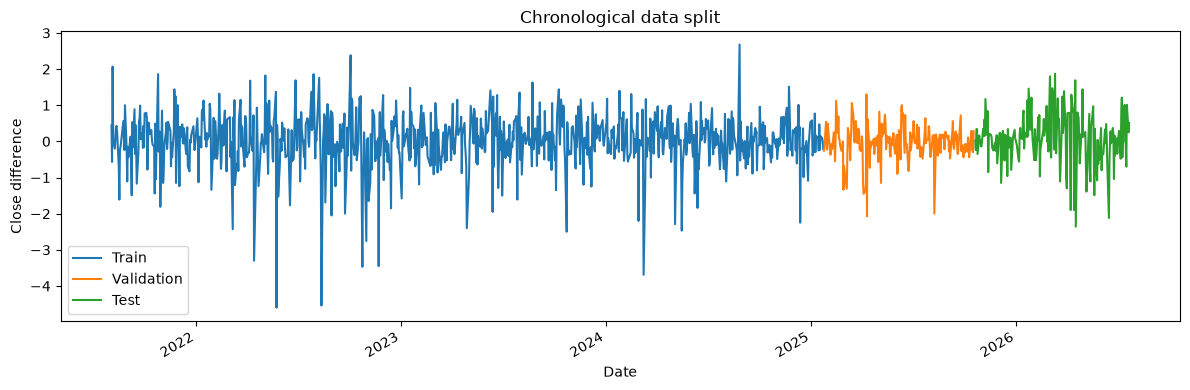

In [21]:
n_observations = len(series)
train_end = int(n_observations * 0.70)
validation_end = int(n_observations * 0.85)

train = series.iloc[:train_end]
validation = series.iloc[train_end:validation_end]
test = series.iloc[validation_end:]

if min(len(train), len(validation), len(test)) == 0:
    raise ValueError("The time series is too short for a 70/15/15 split.")

split_summary = pd.DataFrame({
    "observations": [len(train), len(validation), len(test)],
    "start_date": [train.index.min().date(), validation.index.min().date(), test.index.min().date()],
    "end_date": [train.index.max().date(), validation.index.max().date(), test.index.max().date()],
}, index=["train", "validation", "test"])
display(split_summary)

ax = train.plot(figsize=(12, 4), label="Train", color="tab:blue")
validation.plot(ax=ax, label="Validation", color="tab:orange")
test.plot(ax=ax, label="Test", color="tab:green")
ax.set(title="Chronological data split", xlabel="Date", ylabel="Close difference")
ax.legend()
plt.tight_layout()
plt.show()

The time series is split chronologically into training, validation, and test sets while preserving temporal order. This approach prevents data leakage and ensures that model performance is evaluated on observations that occur after the training period, closely reflecting a real forecasting scenario.

## ARIMA order selection

Because `Close_diff` is already differenced, `d=0`. Candidate values from 0 to 4 are evaluated for `p` and `q`, using validation MSE as the selection metric.

In [22]:
train_model = pd.Series(
    train.to_numpy(),
    index=pd.RangeIndex(len(train)),
    name="Close_diff",
)

validation_actual = validation.to_numpy()

search_results = []

for p in range(5):
    for q in range(5):
        order = (p, 0, q)

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                fitted = ARIMA(
                    train_model,
                    order=order,
                    enforce_stationarity=True,
                    enforce_invertibility=True,
                ).fit()

                if not fitted.mle_retvals.get("converged", True):
                    continue

                forecast = fitted.forecast(
                    steps=len(validation_actual)
                ).to_numpy()

            errors = validation_actual - forecast

            search_results.append({
                "p": p,
                "d": 0,
                "q": q,
                "mse": np.mean(errors**2),
                "rmse": np.sqrt(np.mean(errors**2)),
                "mae": np.mean(np.abs(errors)),
                "aic": fitted.aic,
            })

        except (
            ValueError,
            np.linalg.LinAlgError,
            FloatingPointError,
        ):
            continue

if not search_results:
    raise RuntimeError("No ARIMA candidate converged.")

search_results = (
    pd.DataFrame(search_results)
    .sort_values(["mse", "aic"])
    .reset_index(drop=True)
)

search_results.index = search_results.index + 1
search_results.index.name = "rank"

display(
    search_results.head(10).style.format({
        "mse": "{:.6f}",
        "rmse": "{:.6f}",
        "mae": "{:.6f}",
        "aic": "{:.2f}",
    })
)

,p,d,q,mse,rmse,mae,aic
rank,,,,,,,
1,0,0,1,0.245451,0.495430,0.347826,1936.03
2,1,0,0,0.245452,0.495431,0.347827,1936.03
3,0,0,0,0.245455,0.495434,0.347833,1934.06
4,1,0,1,0.245470,0.495450,0.347865,1937.11
5,0,0,2,0.245477,0.495456,0.347885,1935.84
6,2,0,0,0.245477,0.495456,0.347884,1935.83
7,0,0,3,0.245479,0.495458,0.347887,1937.84
8,1,0,4,0.245479,0.495459,0.347888,1941.84
9,1,0,2,0.245480,0.495459,0.347888,1937.84


In [23]:
best_row = search_results.iloc[0]
best_order = (int(best_row["p"]), int(best_row["d"]), int(best_row["q"]))

print(f"Selected model : ARIMA{best_order}")
print(f"Validation MSE : {best_row['mse']:.6f}")
print(f"Validation RMSE: {best_row['rmse']:.6f}")
print(f"Validation MAE : {best_row['mae']:.6f}")
print(f"Training AIC   : {best_row['aic']:.2f}")

Selected model : ARIMA(0, 0, 1)
Validation MSE : 0.245451
Validation RMSE: 0.495430
Validation MAE : 0.347826
Training AIC   : 1936.03


ARIMA(0, 0, 1) achieved the lowest validation MSE among the evaluated candidates and was therefore selected for the final training stage. Although several specifications produced nearly identical validation errors, the model was selected according to the predefined validation criterion.

## Final fit and artifacts

The selected model is fitted on training plus validation data. The untouched test period will be evaluated in `05_forecasting.ipynb`.

In [24]:
train_validation = pd.concat([train, validation])

train_validation_model = pd.Series(
    train_validation.to_numpy(),
    index=pd.RangeIndex(len(train_validation)),
    name="Close_diff",
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    final_model = ARIMA(
        train_validation_model,
        order=best_order,
        enforce_stationarity=True,
        enforce_invertibility=True,
    ).fit()

display(final_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Close_diff   No. Observations:                 1053
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1118.285
Date:                Tue, 21 Jul 2026   AIC                           2242.571
Time:                        22:32:45   BIC                           2257.449
Sample:                             0   HQIC                          2248.211
                               - 1053                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0032      0.024      0.130      0.897      -0.044       0.051
ma.L1          0.0167      0.029      0.576      0.564      -0.040       0.073
sigma2         0.4897      0.012     42.040      0.000       0.467       0.513
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              2026.80
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.37   Skew:                            -1.25
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The final ARIMA(0, 0, 1) model was fitted using the combined training and validation periods. Neither the constant nor the MA(1) coefficient is statistically significant, suggesting limited linear dependence in the first-differenced closing-price series.

The Ljung–Box result indicates no remaining autocorrelation at the first lag. However, the residuals are non-normal and heteroskedastic, with pronounced skewness and excess kurtosis. Therefore, the ARIMA model may capture the conditional mean reasonably well, but it does not adequately represent the time-varying volatility and extreme movements observed in the series.

In [25]:
metadata = {
    "target": "Close_diff",
    "order": list(best_order),
    "train_end": train.index.max().date().isoformat(),
    "validation_end": validation.index.max().date().isoformat(),
    "test_start": test.index.min().date().isoformat(),
    "test_observations": len(test),
    "validation_mse": float(best_row["mse"]),
    "validation_mae": float(best_row["mae"]),
}

MODEL_DIR.mkdir(parents=True, exist_ok=True)
final_model.save(MODEL_PATH)
search_results.to_csv(SEARCH_PATH, index=False)
METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8");

## Modeling decision

The ARIMA order is selected based on validation-set performance, while the test set remains completely isolated until the final evaluation. This separation prevents information leakage and avoids overly optimistic performance estimates caused by using future observations during model selection.